# Chronic Disease Prediction — XGBoost V2 (Final Model)

**Model:** XGBoost with `RandomizedSearchCV` (100 iterations, 5-fold CV)  
**Data:** EPA EQI (2011–2015) merged with CDC PLACES (2020), ~71k census tracts  
**Targets:** 4 chronic disease prevalence measures (STROKE, KIDNEY, CHD, CANCER)  
**Features:** 37 environmental, demographic, and health behavior variables  
**Preprocessing:** Median imputation → MinMaxScaler → stratified 80/20 train/test split by State

---
## 1. Setup & Data Loading

In [3]:
# base imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# sklearn imports
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

# pandas display options
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)

# load data
cdc_epa_data = pd.read_csv(
    "/Users/virginiaberthy/UVA-MSDS/DS 5003 - Healthcare DS - SP '26/Group Project/FINAL MODEL & RUN/EQI_2011_2015_PLACES_2020_merged_copy.csv"
)
print(f"Loaded: {cdc_epa_data.shape[0]:,} rows, {cdc_epa_data.shape[1]} columns")

Loaded: 70,962 rows, 73 columns


---
## 2. Variable Selection & Train/Test Split

In [4]:
variables_of_interest = [
    'X_pop_dens', 'facilities_area', 'pest', 'bs_25yo', 'time2work', 'crime_index',
    'education_area', 'food_ratio', 'nindex_open', 'nata_sum', 'ozone', 'pm25',
    'poverty', 'rent_income_pct', 'selfservice', 'unemployment',
    'PLACES_ACCESS2', 'PLACES_ARTHRITIS', 'PLACES_BINGE', 'PLACES_BPHIGH', 'PLACES_BPMED',
    'PLACES_CASTHMA', 'PLACES_CERVICAL', 'PLACES_CHD', 'PLACES_CHECKUP',
    'PLACES_CHOLSCREEN', 'PLACES_COLON_SCREEN', 'PLACES_COPD', 'PLACES_COREM',
    'PLACES_COREW', 'PLACES_CSMOKING', 'PLACES_DENTAL', 'PLACES_DIABETES',
    'PLACES_HIGHCHOL', 'PLACES_KIDNEY', 'PLACES_LPA', 'PLACES_MAMMOUSE',
    'PLACES_MHLTH', 'PLACES_OBESITY', 'PLACES_PHLTH', 'PLACES_SLEEP', 'PLACES_STROKE',
    'PLACES_TEETHLOST', 'PLACES_CANCER',
    'RUCA_pri_cat',
    'tract_fips', 'State', 'County', 'StateAbbr', 'CountyName',
]

cdc_epa_selected = cdc_epa_data[variables_of_interest]

# stratified 80/20 split by state
cdc_epa_train, cdc_epa_test = train_test_split(
    cdc_epa_selected, test_size=0.2, random_state=5003,
    stratify=cdc_epa_selected['State']
)

print(f"Train: {len(cdc_epa_train):,}  Test: {len(cdc_epa_test):,}")
print(f"\nMissing values in train:\n{cdc_epa_train.isnull().sum()[cdc_epa_train.isnull().sum() > 0]}")

Train: 56,769  Test: 14,193

Missing values in train:
PLACES_COLON_SCREEN     2
PLACES_COREM           43
PLACES_COREW           38
PLACES_MAMMOUSE         6
PLACES_TEETHLOST       24
dtype: int64


---
## 3. Define Targets, Features, and Hyperparameter Grid

In [5]:
targets = [
    'PLACES_STROKE', 'PLACES_KIDNEY',
    'PLACES_CHD', 'PLACES_CANCER',
]

id_cols = ['tract_fips', 'State', 'County', 'StateAbbr', 'CountyName']

feature_cols = [c for c in cdc_epa_train.columns if c not in id_cols + targets]
num_cols = [c for c in feature_cols if cdc_epa_train[c].dtype in ['float64', 'int64']]

print(f"Features: {len(feature_cols)}  |  Numeric: {len(num_cols)}  |  Targets: {len(targets)}")

xgb_params_v2 = {
    'n_estimators': [400, 500, 600, 800],
    'max_depth': [6, 7, 8, 10],
    'learning_rate': [0.03, 0.05, 0.07],
    'subsample': [0.75, 0.8, 0.85],
    'colsample_bytree': [0.6, 0.7, 0.8],
    'min_child_weight': [1, 3, 5],
    'reg_alpha': [0, 0.01, 0.1, 1],
    'reg_lambda': [0.5, 1, 2, 5],
    'gamma': [0, 0.1, 0.3],
}

Features: 37  |  Numeric: 37  |  Targets: 8


---
## 4. XGBoost V2 — RandomizedSearchCV (Primary Results)

In [6]:
results_v2 = []

for target in targets:
    X_train = cdc_epa_train[feature_cols].copy()
    y_train = cdc_epa_train[target]
    X_test = cdc_epa_test[feature_cols].copy()
    y_test = cdc_epa_test[target]

    imputer = SimpleImputer(strategy='median')
    X_train[num_cols] = imputer.fit_transform(X_train[num_cols])
    X_test[num_cols] = imputer.transform(X_test[num_cols])

    scaler = MinMaxScaler()
    X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
    X_test[num_cols] = scaler.transform(X_test[num_cols])

    xgb_cv = RandomizedSearchCV(
        XGBRegressor(random_state=5003),
        xgb_params_v2, n_iter=100, cv=5, scoring='r2',
        random_state=5003, n_jobs=-1
    )
    xgb_cv.fit(X_train, y_train)

    y_pred = xgb_cv.predict(X_test)
    rmse = round(np.sqrt(mean_squared_error(y_test, y_pred)), 4)
    r2 = round(r2_score(y_test, y_pred), 4)
    best = xgb_cv.best_params_

    print(f"{target.replace('PLACES_', ''):12s}  R²: {r2}  RMSE: {rmse}")

    results_v2.append({
        'Target': target.replace('PLACES_', ''),
        'R²': r2, 'RMSE': rmse,
        'best_params': best,
        'model': xgb_cv.best_estimator_,
        'imputer': imputer,
        'scaler': scaler,
        'y_test': y_test.values,
        'y_pred': y_pred,
    })

results_v2_df = pd.DataFrame(results_v2).sort_values('R²', ascending=False)
results_v2_df[['Target', 'R²', 'RMSE']]

/opt/miniconda3/envs/ml-course/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


STROKE        R²: 0.9903  RMSE: 0.1233


/opt/miniconda3/envs/ml-course/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


KIDNEY        R²: 0.9868  RMSE: 0.0953


/opt/miniconda3/envs/ml-course/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


...

/opt/miniconda3/envs/ml-course/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


ARTHRITIS     R²: 0.9858  RMSE: 0.793


/opt/miniconda3/envs/ml-course/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CASTHMA       R²: 0.9755  RMSE: 0.2443


,Target,R²,RMSE
5,COPD,0.9914,0.2509
0,STROKE,0.9903,0.1233
2,DIABETES,0.9896,0.3831
1,KIDNEY,0.9868,0.0953
3,CHD,0.9865,0.2586
6,ARTHRITIS,0.9858,0.7930
4,CANCER,0.9839,0.2354
7,CASTHMA,0.9755,0.2443


---
## 5. Best Hyperparameters Table

In [7]:
params_df = pd.DataFrame([
    {'Target': r['Target'], 'R²': r['R²'], 'RMSE': r['RMSE'], **r['best_params']}
    for r in results_v2
]).sort_values('R²', ascending=False)
params_df

,Target,R²,RMSE,subsample,reg_lambda,reg_alpha,n_estimators,min_child_weight,max_depth,learning_rate,gamma,colsample_bytree
5,COPD,0.9914,0.2509,0.8500,2.0000,1.0000,800,5,7,0.0700,0,0.6000
0,STROKE,0.9903,0.1233,0.8500,2.0000,1.0000,800,5,7,0.0700,0,0.6000
2,DIABETES,0.9896,0.3831,0.8500,2.0000,1.0000,800,5,7,0.0700,0,0.6000
1,KIDNEY,0.9868,0.0953,0.7500,0.5000,0.1000,800,5,8,0.0700,0,0.8000
3,CHD,0.9865,0.2586,0.8500,2.0000,1.0000,800,5,7,0.0700,0,0.6000
6,ARTHRITIS,0.9858,0.7930,0.7500,2.0000,0.0100,800,1,8,0.0700,0,0.6000
4,CANCER,0.9839,0.2354,0.7500,0.5000,0.1000,800,5,8,0.0700,0,0.8000
7,CASTHMA,0.9755,0.2443,0.7500,0.5000,0.1000,800,5,8,0.0700,0,0.8000


---
## 6. Actual vs Predicted Scatter Plots (National)

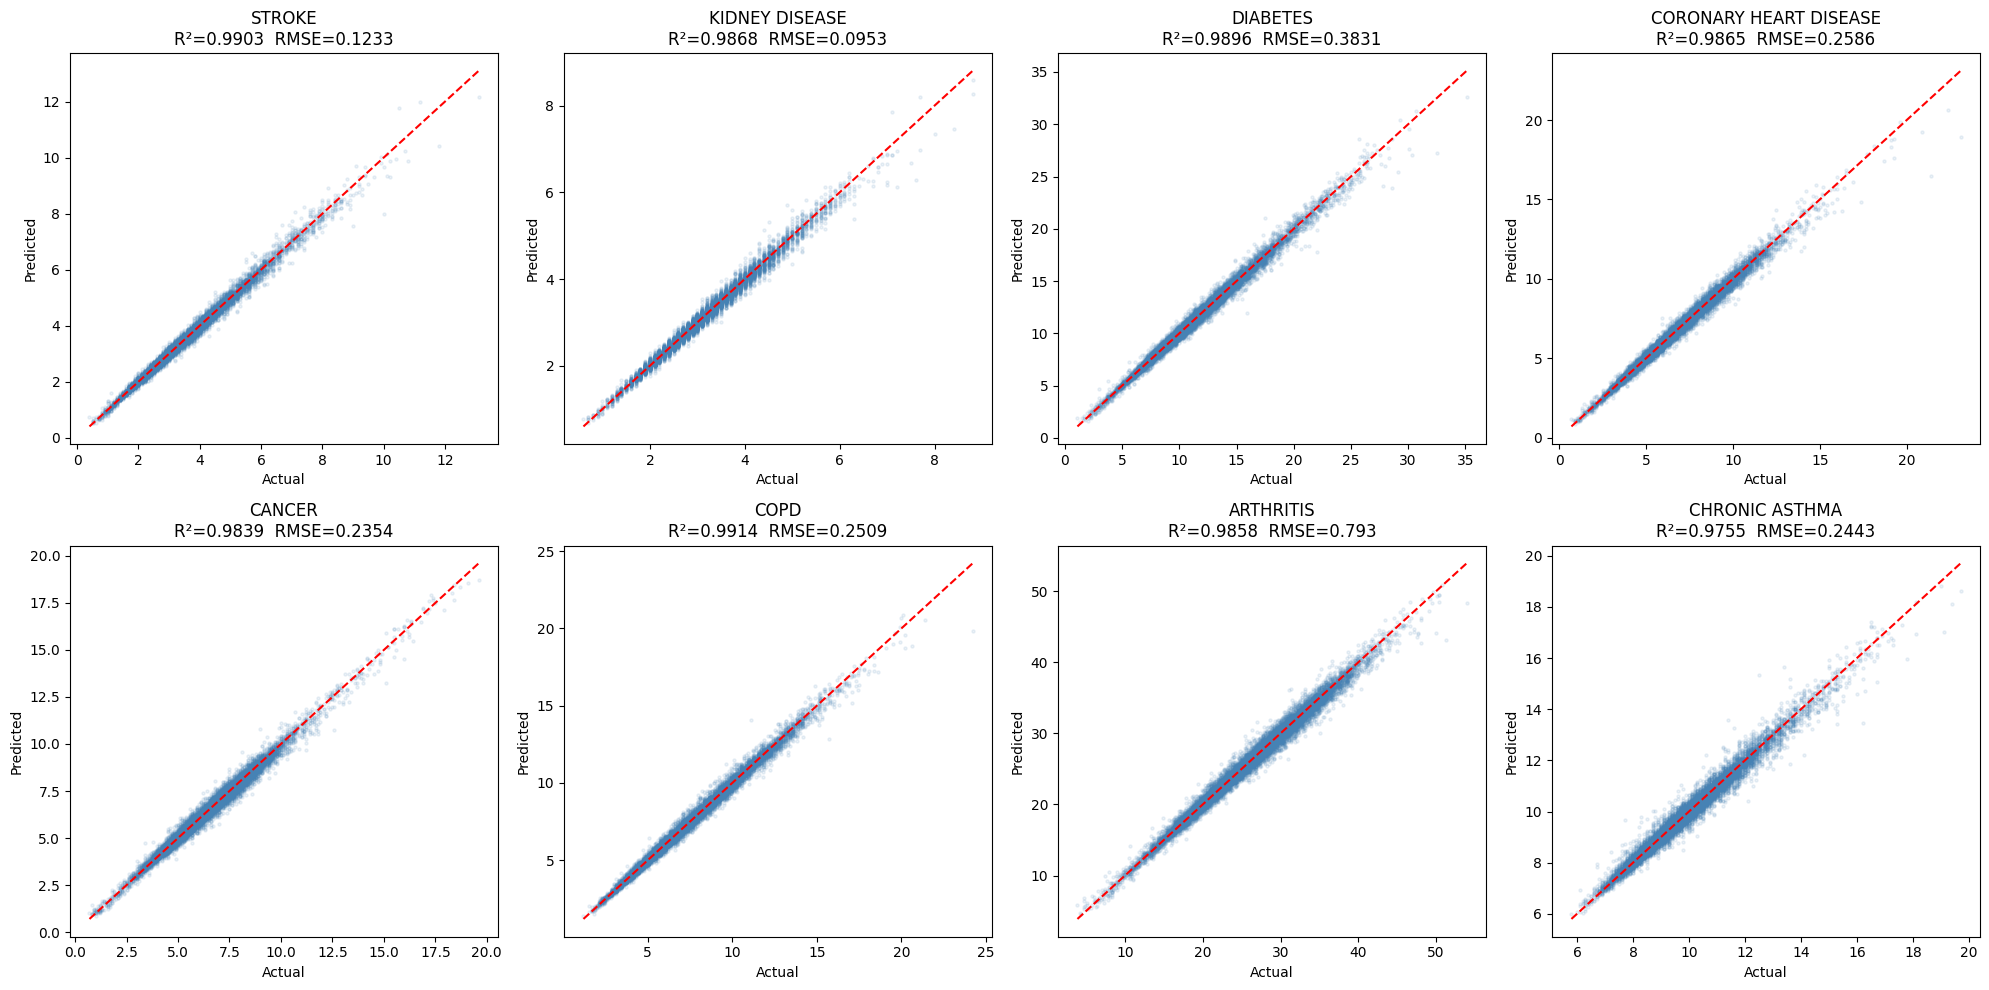

In [8]:
name_map = {
    'STROKE': 'STROKE', 'KIDNEY': 'KIDNEY DISEASE',
    'CANCER': 'CANCER', 'DIABETES': 'DIABETES',
    'COPD': 'COPD', 'ARTHRITIS': 'ARTHRITIS',
    'CHD': 'CORONARY HEART DISEASE', 'CASTHMA': 'CHRONIC ASTHMA',
}

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, row in enumerate(results_v2):
    ax = axes[i]
    ax.scatter(row['y_test'], row['y_pred'], alpha=0.1, s=5, color='steelblue')
    lo = min(row['y_test'].min(), row['y_pred'].min())
    hi = max(row['y_test'].max(), row['y_pred'].max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    ax.set_title(f"{name_map[row['Target']]}\nR²={row['R²']}  RMSE={row['RMSE']}")
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('xgb_v2_actual_vs_predicted_national.png', dpi=150)
plt.show()

---
## 7. State-Level Evaluation

In [9]:
def evaluate_state(state_fips, state_name, results, test_df):
    """Evaluate model performance for a single state."""
    idx = np.where(test_df['State'] == state_fips)[0]
    print(f"\n{'='*50}")
    print(f"{state_name} (n={len(idx)} tracts)")
    print(f"{'='*50}")
    for row in results:
        y_test_st = row['y_test'][idx]
        y_pred_st = row['y_pred'][idx]
        rmse = round(np.sqrt(mean_squared_error(y_test_st, y_pred_st)), 4)
        r2 = round(r2_score(y_test_st, y_pred_st), 4)
        print(f"{row['Target']:12s}  R²: {r2}  RMSE: {rmse}")

# Virginia
evaluate_state(51, 'Virginia', results_v2, cdc_epa_test)

# California
evaluate_state(6, 'California', results_v2, cdc_epa_test)

# Wyoming
evaluate_state(56, 'Wyoming', results_v2, cdc_epa_test)

# Maine
evaluate_state(23, 'Maine', results_v2, cdc_epa_test)

# Vermont
evaluate_state(50, 'Vermont', results_v2, cdc_epa_test)

# Washington, D.C.
evaluate_state(11, 'Washington, D.C.', results_v2, cdc_epa_test)

# Georgia
evaluate_state(13, 'Georgia', results_v2, cdc_epa_test)

# Florida
evaluate_state(12, 'Florida', results_v2, cdc_epa_test)


Virginia (n=369 tracts)
STROKE        R²: 0.9919  RMSE: 0.1116
KIDNEY        R²: 0.9894  RMSE: 0.0834
DIABETES      R²: 0.9896  RMSE: 0.3495
CHD           R²: 0.9874  RMSE: 0.2469
CANCER        R²: 0.9808  RMSE: 0.2527
COPD          R²: 0.9942  RMSE: 0.199
ARTHRITIS     R²: 0.9863  RMSE: 0.7642
CASTHMA       R²: 0.9798  RMSE: 0.2072

California (n=1588 tracts)
STROKE        R²: 0.9855  RMSE: 0.1065
KIDNEY        R²: 0.9863  RMSE: 0.0802
DIABETES      R²: 0.9864  RMSE: 0.3403
CHD           R²: 0.9862  RMSE: 0.1904
CANCER        R²: 0.9887  RMSE: 0.2009
COPD          R²: 0.9878  RMSE: 0.1853
ARTHRITIS     R²: 0.9832  RMSE: 0.6439
CASTHMA       R²: 0.9733  RMSE: 0.1964

Wyoming (n=26 tracts)
STROKE        R²: 0.9807  RMSE: 0.1141
KIDNEY        R²: 0.9722  RMSE: 0.1022
DIABETES      R²: 0.9689  RMSE: 0.4357
CHD           R²: 0.9834  RMSE: 0.228
CANCER        R²: 0.9811  RMSE: 0.2574
COPD          R²: 0.977  RMSE: 0.2436
ARTHRITIS     R²: 0.9745  RMSE: 0.9425
CASTHMA       R²: 0.8421  RMSE

---
## 8. Virginia Scatter Plots

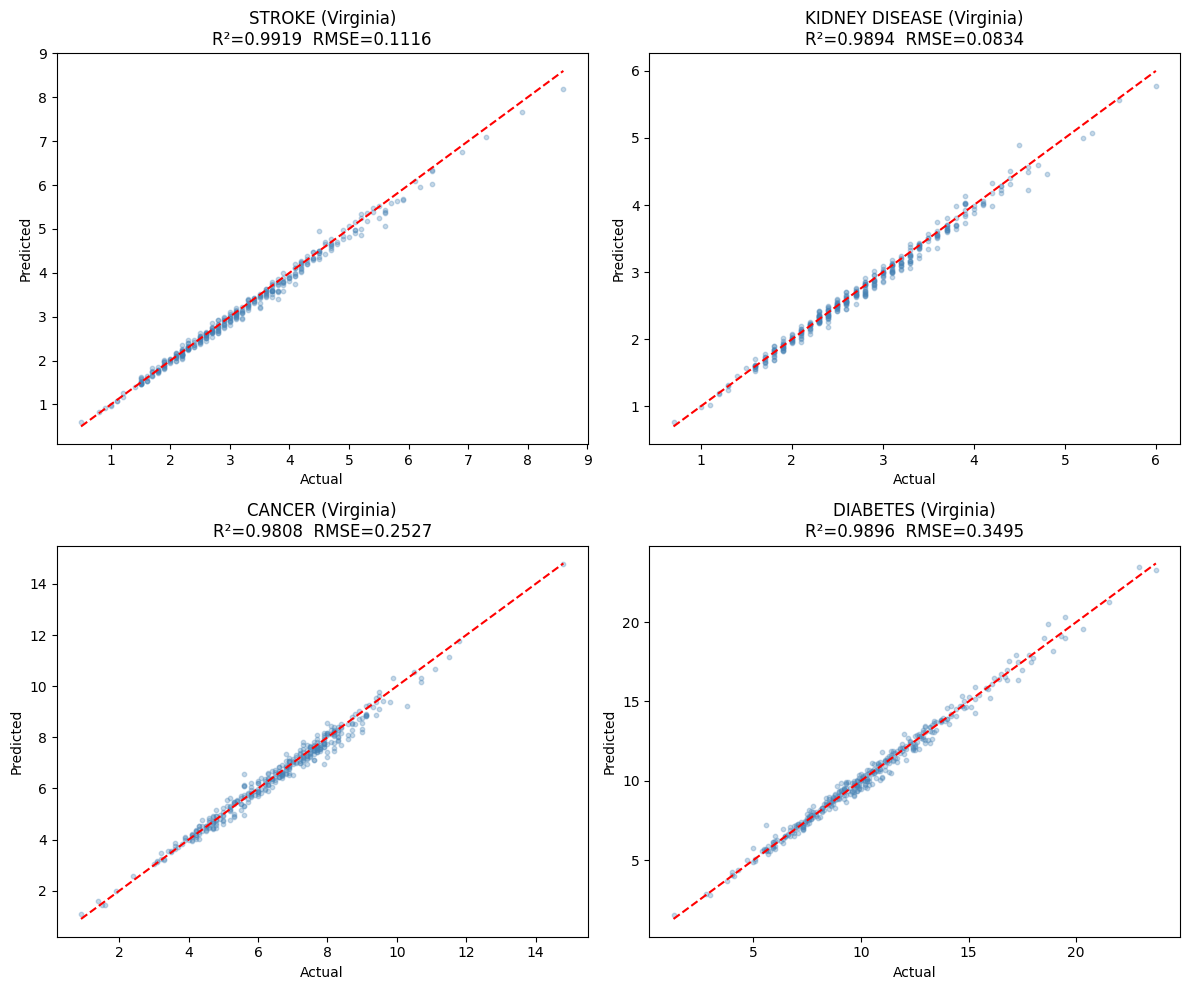

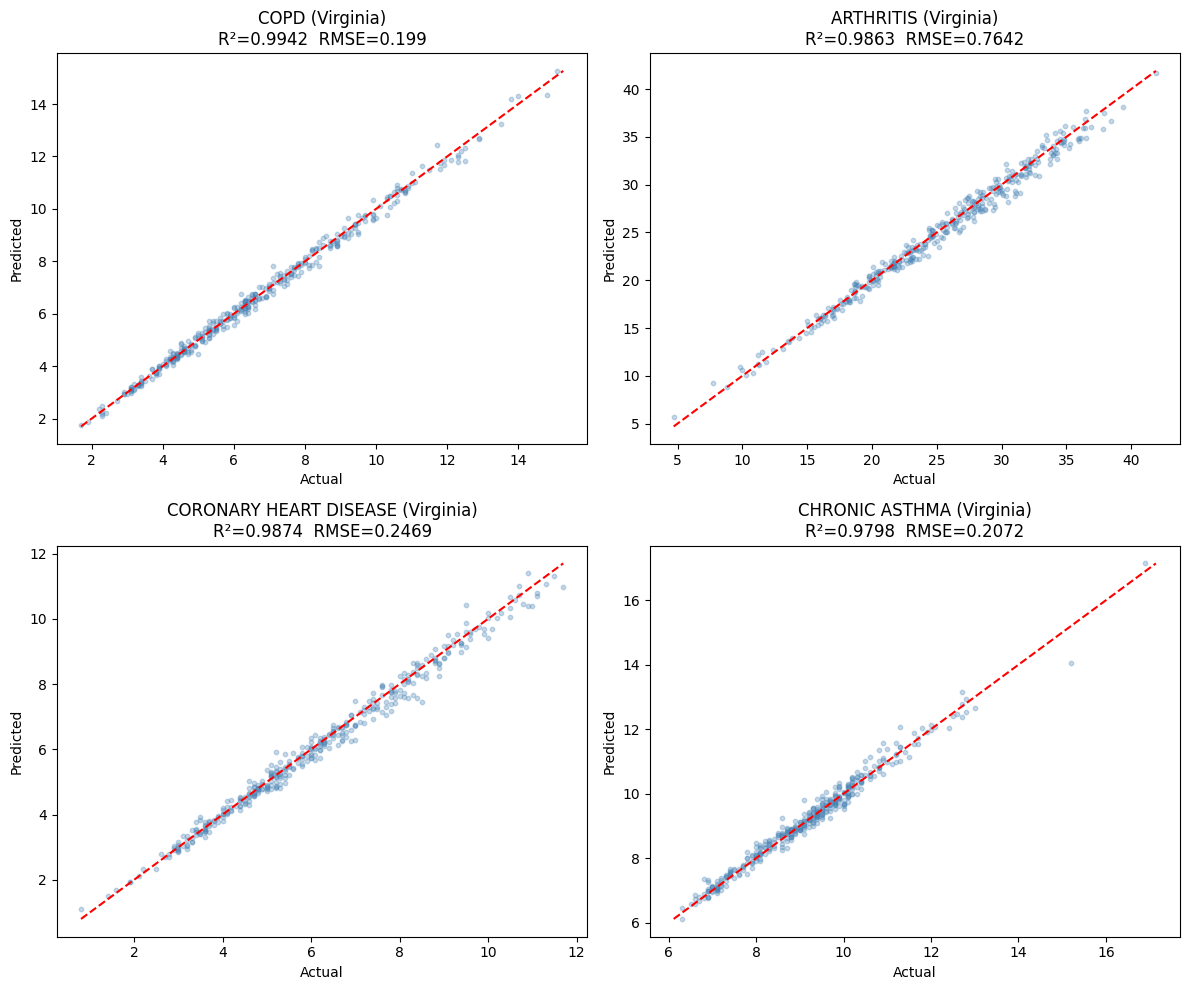

In [10]:
va_idx = np.where(cdc_epa_test['State'] == 51)[0]
v2_lookup = {row['Target']: row for row in results_v2}

group = ['STROKE', 'KIDNEY', 'CANCER', 'CHD']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, target in enumerate(group):
    row = v2_lookup[target]
    y_test_va = row['y_test'][va_idx]
    y_pred_va = row['y_pred'][va_idx]

    rmse = round(np.sqrt(mean_squared_error(y_test_va, y_pred_va)), 4)
    r2 = round(r2_score(y_test_va, y_pred_va), 4)

    ax = axes[i]
    ax.scatter(y_test_va, y_pred_va, alpha=0.3, s=10, color='steelblue')
    lo = min(y_test_va.min(), y_pred_va.min())
    hi = max(y_test_va.max(), y_pred_va.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1.5)
    ax.set_title(f"{name_map[target]} (Virginia)\nR²={r2}  RMSE={rmse}")
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')

plt.tight_layout()
plt.savefig('xgb_v2_VA_scatter.png', dpi=150)
plt.show()

---
## 9. Virginia County-Level Predictions & Ranking
Uses saved models to predict ALL Virginia tracts, then aggregates to county.

In [11]:
# get all Virginia tracts
va_all = cdc_epa_selected[cdc_epa_selected['State'] == 51].copy()
X_va = va_all[feature_cols].copy()

# predict each target using saved models with matching preprocessing
for row in results_v2:
    X_va_proc = va_all[feature_cols].copy()
    X_va_proc[num_cols] = row['imputer'].transform(X_va_proc[num_cols])
    X_va_proc[num_cols] = row['scaler'].transform(X_va_proc[num_cols])
    va_all[f"pred_{row['Target']}"] = row['model'].predict(X_va_proc)

# aggregate to county — mean predicted prevalence
agg_dict = {'tract_fips': 'count'}
for row in results_v2:
    t = row['Target']
    agg_dict[f'PLACES_{t}'] = 'mean'
    agg_dict[f'pred_{t}'] = 'mean'

va_county = va_all.groupby('CountyName').agg(agg_dict).round(2)
va_county.rename(columns={'tract_fips': 'n_tracts'}, inplace=True)

# show top counties by predicted cancer prevalence
va_county.sort_values('pred_CANCER', ascending=False).head(20)

,n_tracts,PLACES_STROKE,pred_STROKE,PLACES_KIDNEY,pred_KIDNEY,PLACES_DIABETES,pred_DIABETES,PLACES_CHD,pred_CHD,PLACES_CANCER,pred_CANCER,PLACES_COPD,pred_COPD,PLACES_ARTHRITIS,pred_ARTHRITIS,PLACES_CASTHMA,pred_CASTHMA
CountyName,,,,,,,,,,,,,,,,,
Petersburg,11,6.0200,5.9400,4.4500,4.4200,19.2400,19.0100,8.5200,8.4900,6.3100,6.2700,9.6400,9.6200,31.6800,31.7400,12.2400,12.2200
Emporia,2,6.3000,6.2600,4.7000,4.6700,18.6500,18.6600,9.9500,9.8900,7.1500,7.1100,11.1500,11.1700,33.8500,33.8500,12.0000,12.0300
Franklin City,2,5.7000,5.6100,4.3000,4.2800,17.2500,17.2700,8.7000,8.8000,7.3000,7.3000,9.8500,9.8400,32.3000,32.3400,11.6500,11.5600
Greensville,2,5.6000,5.5600,4.2500,4.2400,17.5500,17.2700,9.2500,9.2100,7.2000,7.2500,10.3000,10.4200,33.1500,33.2100,11.3000,11.3300
Danville,15,5.5500,5.5100,4.2700,4.2800,16.9000,16.9100,9.4500,9.4000,7.6900,7.6900,10.4600,10.3000,32.4400,32.6400,11.1400,11.1500
Martinsville,5,5.5400,5.5100,4.3000,4.3000,16.8600,16.8800,9.4400,9.3800,7.8200,7.7800,10.2800,10.2000,33.3200,33.1100,11.1400,11.1200
Brunswick,4,5.4200,5.3700,4.1500,4.1300,16.5800,16.6600,8.9500,8.8900,7.2500,7.2700,9.8800,9.8300,33.7200,33.7400,11.2500,11.2600
Lunenburg,3,5.3000,5.2600,4.0300,4.0700,16.4700,16.3300,9.6300,9.6400,7.5000,7.4600,10.7000,10.7400,32.7300,33.4600,10.7300,10.6200
Northampton,3,5.4300,5.3700,4.2300,4.2200,16.2300,16.2700,9.9300,10.0500,8.5000,8.5200,10.2300,10.2900,35.1700,35.0500,10.3700,10.3600


### Heatmaps

In [20]:
import plotly.express as px

# build county FIPS as 5-digit string (state + county)
va_county_plot = va_county.reset_index()
va_fips = va_all.groupby('CountyName')[['State', 'County']].first().reset_index()
va_fips['FIPS'] = va_fips['State'].astype(str).str.zfill(2) + va_fips['County'].astype(str).str.zfill(3)
va_county_plot = va_county_plot.merge(va_fips[['CountyName', 'FIPS']], on='CountyName')

from urllib.request import urlopen
import json
with urlopen('https://raw.githubusercontent.com/plotly/datasets/master/geojson-counties-fips.json') as response:
    counties_geo = json.load(response)

for target in ['STROKE', 'KIDNEY', 'CANCER', 'CHD']:
    fig = px.choropleth(
        va_county_plot, geojson=counties_geo,
        locations='FIPS', color=f'pred_{target}',
        color_continuous_scale='YlOrRd',
        scope='usa',
        title=f'Predicted {target} Prevalence (%) — Virginia Counties',
        labels={f'pred_{target}': 'Prevalence (%)'},
    )
    fig.update_geos(fitbounds='locations', visible=False)
    fig.write_html(f'va_{target}_map.html')
    print(f"Saved va_{target}_map.html")

Saved va_DIABETES_map.html
Saved va_STROKE_map.html
Saved va_KIDNEY_map.html
Saved va_CANCER_map.html
Saved va_CHD_map.html


In [21]:
# Max, Min & Mean KIDNEY for Virignia counties
print(f"Virginia County Predicted KIDNEY Prevalence (%)")
print(f"Max: {va_county['pred_KIDNEY'].max():.2f}%")
print(f"Min: {va_county['pred_KIDNEY'].min():.2f}%")
print(f"Mean: {va_county['pred_KIDNEY'].mean():.2f}%")  

Virginia County Predicted KIDNEY Prevalence (%)
Max: 4.67%
Min: 1.78%
Mean: 3.18%


In [22]:
va_all['PLACES_KIDNEY'].agg(['min', 'max', 'mean']).round(2)

min    0.7000
max    7.2000
mean   2.7500
Name: PLACES_KIDNEY, dtype: float64

In [23]:
va_all[['PLACES_KIDNEY', 'pred_KIDNEY']].agg(['min', 'max', 'mean']).round(2)

,PLACES_KIDNEY,pred_KIDNEY
min,0.7000,0.7100
max,7.2000,7.2100
mean,2.7500,2.7400
